In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
June 11 2026

@author: Jenny Huang
@contact: huan1428@umn.edu

"""
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Model
Each conduit node has a corresponding storage node meant to represent the bedrock matrix. Mass transfer between conduit and storage is governed by a linear transfer function dependent on the head difference between the conduit and storage node. 

Flow from the storage node to the conduit node is defined: 

$Q = kA(h_s - h_c)$

where $k$ is an exchange rate coefficient and $A$ is the surface area of the reservoir.

If $h_s > h_c$, Q is positive and flow goes from storage to conduit. If $h_c > h_s$, flow reverses and goes from conduit into reservoir. 

The head in the reservoir is updated using an explicit time-stepping scheme:

$\frac{h_s^{t+1} - h_s^t}{\Delta t} = \frac{1}{S_y A}(R^t - Q^t)$  

where $S_y$ is specific yield. Solving for the storage head at the next timestep is thus: 

$h_s^{t+1} = h_s^t + \frac{\Delta t}{S_y A}(R^t - Q^t)$  

The conduit head is updated at each timestep by approximating the conduit as a prism with a proportional depth and volume change: 

$\Delta V = (Q_{in} - Q_{out})\Delta t$

$Q_{in}$ is the flow from the storage node and $Q_{out}$ is the flow out of the conduit node. The change in water level in the conduit is then calculated as:

$\Delta y = \Delta V / A_{surface}$ 

where where $A_{surface}$ is the effective surface area in the conduit and is determined with an approximation of the effective width of the water surface (w) and a given parameter of conduit length (L):

$w = 2 \sqrt{2 R y- y^2}$

where R is the radius of the conduit and y is the current water level

$A_{surface} = wL$ 


In [ ]:
class StorageNode:
    def __init__(self, K, S_y, A, h_0,): 
        """A storage node that has properties kappa (K [L/T]), 
        specific yield (S_y[-]), and surface area (A [L^2]) and initial water height (h_0)"""
        self.K = K
        self.S_y = S_y
        self.h = h_0
        self.A = A

    def update_head(self, R, h_conduit, dt): 
        #compute Q out of node, apply recharge, which is volumetric (?) TODO: finalize R implementation-- i think volumetric to be compatible with OK 

        Q = self.K * self.A * (self.h - h_conduit) # if h > h_conduit, then Q > 0 (which is subtracted in the update)
        self.h = max(self.h + (R - Q) / (self.S_y * self.A) * dt, 0) # balance mass, R - Q then / S_y * A 
        return self.h, Q
    
class ConduitNode:
    def __init__(self, y_0, d, L):
        """Simple conduit node that has properties of water height (h [L]), diameter (d [L]), and length (L [L])"""
        self.y = y_0
        self.d = d
        self.L = L
        self.conduit_volume = np.pi * (d/2)**2 * L
        self.surface_area = self.calculate_surface_area()
        self.V = self.volume_from_depth()
    def volume_from_depth(self):
        y = self.y
        R = self.d / 2

        y = np.clip(y, 0, self.d)

        A = (
            R**2 * np.arccos((R - y) / R)
            - (R - y) * np.sqrt(np.maximum(2 * R * y - y**2, 0))
        )
        return A * self.L
    
    def calculate_surface_area(self):
        #formula: (w) width = 2 * sqrt(2*R*y- y**2)
        effective_d = min(self.d, self.y)
        w = 2 * np.sqrt(self.d * self.y- self.y**2)
        self.surface_area = max(w * self.L, 1e-6)
        return self.surface_area
    
    def update_conduit(self, Q_in, Q_out, dt):
        #update volume based on inflow and outflow, then update head based on new volume 
        dV = (Q_in - Q_out) * dt
        self.calculate_surface_area()
        dy = dV / self.surface_area
        self.V = max(self.V + dV, 0)
        self.y = max(self.y + dy, 0)
        return self.y, self.V


In [95]:
def gaussian_recharge(t, t_peak, magnitude, duration):
    sigma = duration / 6  # 3-sigma rule, ~99% of pulse in 'duration'
    return magnitude * np.exp(-0.5 * ((t - t_peak) / sigma) ** 2)

In [115]:
#example
#discretization
t_max = 100000 # time step in seconds
dt = 1 # time step in seconds
time = np.arange(0, t_max, dt)
h_storage_series = []
h_conduit_series = []
Q_out_series = []
surface_area_series = [] 

#storage parameters
K = 1e-8 # m/s
S_y = 0.15 # - 
A = 50e6 # m^2 
h_0_storage = .05 # m

#Recharge series
baseflow = 0. * A
peak = 0.0001 * A 
R = np.ones(t_max) * baseflow
R[1000:1500] = peak
R[5000:5500] = peak

R = gaussian_recharge(time, t_peak = 1000, magnitude = peak, duration = 500) + gaussian_recharge(time, t_peak = 5000, magnitude = peak, duration = 500)
#conduit params
L = 30e3 # m 
d = 1 # m 
h_0_conduit = 0.1 # m
storage = StorageNode(K = K, S_y = S_y, A = A, h_0 = h_0_storage)
conduit = ConduitNode(y_0 = h_0_conduit, d = d, L = L)
Q_out_conduit = 10 # m^3/s, constant outflow from conduit for testing

<Axes: >

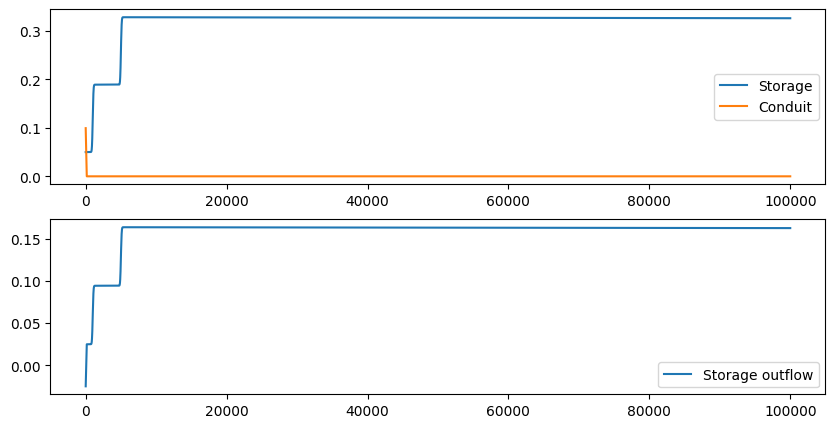

In [116]:
for ts in range(len(time)): 
    R_ts =R[ts]
    h_storage, Q_out = storage.update_head(R_ts, conduit.y, dt)
    h_conduit, V_conduit = conduit.update_conduit(Q_in = Q_out, Q_out = Q_out_conduit, dt = dt) # assume constant outflow of 0.5 m^3/s for now
    h_storage_series.append(h_storage)
    h_conduit_series.append(h_conduit)
    Q_out_series.append(Q_out)
    surface_area_series.append(conduit.surface_area)
fig, ax = plt.subplots(2,1, figsize=(10, 5))
sns.lineplot(x=time, y= h_storage_series, ax = ax[0], label = "Storage")
sns.lineplot(x=time, y=h_conduit_series, ax = ax[0], label = "Conduit")
sns.lineplot(x=time,y= Q_out_series, label = "Storage outflow", ax = ax[1])
# plt.show()
# ax[0].set_xlim(0,500)

In [80]:
Q_out_series

[5.0,
 np.float64(4.986355555555556),
 np.float64(4.972765489906342),
 np.float64(4.9592294256237475),
 np.float64(4.945746989741502),
 np.float64(4.932317813678473),
 np.float64(4.9189415331632205),
 np.float64(4.905617788160245),
 np.float64(4.892346222797897),
 np.float64(4.87912648529789),
 np.float64(4.865958227906375),
 np.float64(4.8528411068265465),
 np.float64(4.839774782152719),
 np.float64(4.8267589178058525),
 np.float64(4.813793181470468),
 np.float64(4.800877244532936),
 np.float64(4.788010782021089),
 np.float64(4.7751934725451255),
 np.float64(4.7624249982397755),
 np.float64(4.749705044707685),
 np.float64(4.737033300964005),
 np.float64(4.724409459382125),
 np.float64(4.7118332156405565),
 np.float64(4.699304268670909),
 np.float64(4.686822320606945),
 np.float64(4.674387076734676),
 np.float64(4.66199824544349),
 np.float64(4.64965553817827),
 np.float64(4.63735866939247),
 np.float64(4.625107356502161),
 np.float64(4.612901319840977),
 np.float64(4.600740282615972),

In [60]:
max(h_storage_series)

np.float64(0.8650528197241424)